En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

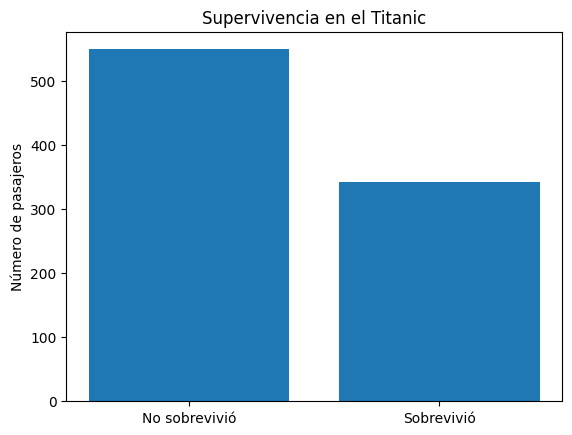

In [ ]:
## Práctica visualización avanzada TITANIC



import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

surv_counts = titanic["survived"].value_counts().sort_index()

plt.figure()
plt.bar(["No sobrevivió", "Sobrevivió"], surv_counts.values)

plt.title("Supervivencia en el Titanic")
plt.ylabel("Número de pasajeros")

plt.savefig("01_supervivencia.png", dpi=300, bbox_inches="tight")
plt.show()

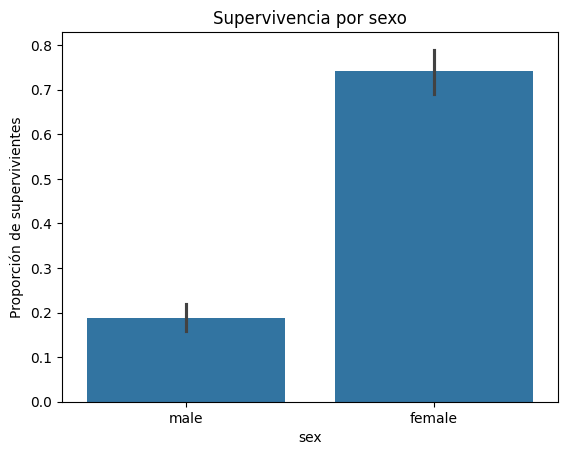

In [2]:
plt.figure()
sns.barplot(data=titanic, x="sex", y="survived")

plt.title("Supervivencia por sexo")
plt.ylabel("Proporción de supervivientes")

plt.savefig("02_sexo.png", dpi=300, bbox_inches="tight")
plt.show()

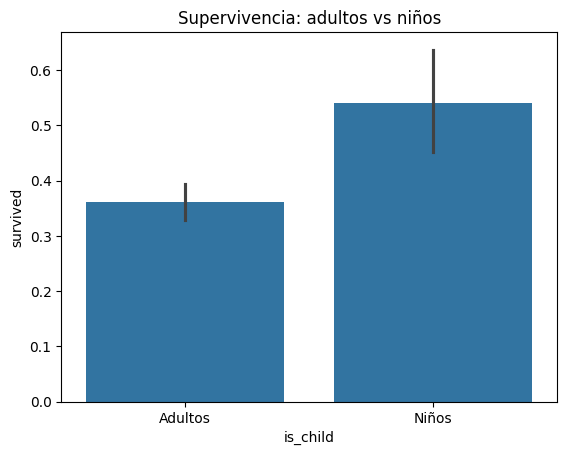

In [3]:
titanic["is_child"] = titanic["age"] < 18

plt.figure()
sns.barplot(data=titanic, x="is_child", y="survived")

plt.xticks([0,1], ["Adultos", "Niños"])
plt.title("Supervivencia: adultos vs niños")

plt.savefig("02b_ninos.png", dpi=300, bbox_inches="tight")
plt.show()

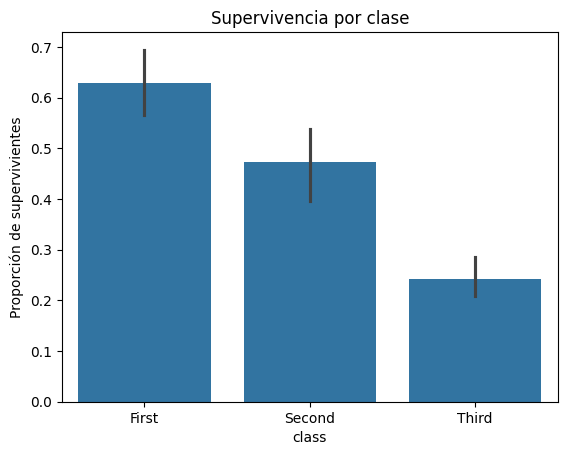

In [4]:
plt.figure()
sns.barplot(data=titanic, x="class", y="survived")

plt.title("Supervivencia por clase")
plt.ylabel("Proporción de supervivientes")

plt.savefig("03_clase.png", dpi=300, bbox_inches="tight")
plt.show()

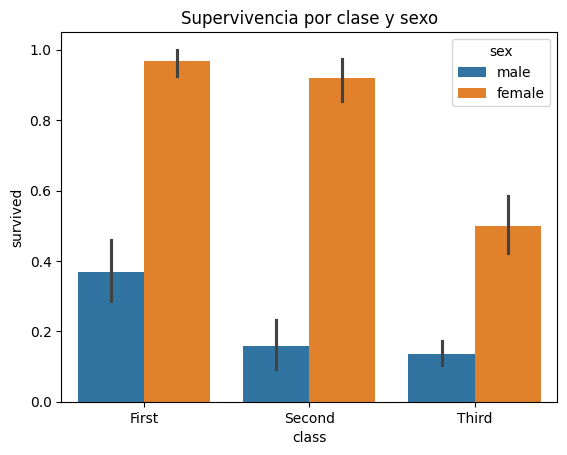

In [5]:
plt.figure()
sns.barplot(data=titanic, x="class", y="survived", hue="sex")

plt.title("Supervivencia por clase y sexo")

plt.savefig("04_clase_sexo.png", dpi=300, bbox_inches="tight")
plt.show()

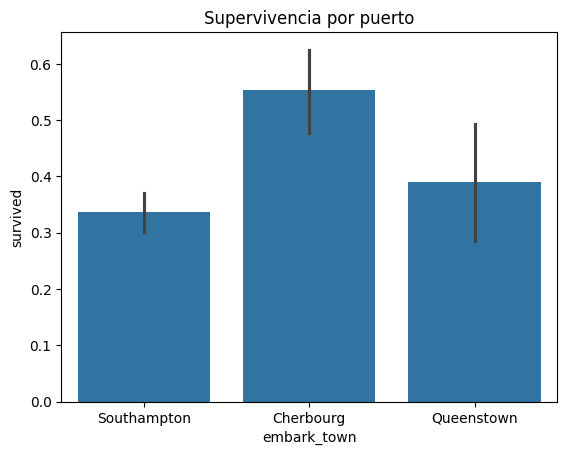

In [6]:
plt.figure()
sns.barplot(data=titanic, x="embark_town", y="survived")

plt.title("Supervivencia por puerto")

plt.savefig("05_puerto.png", dpi=300, bbox_inches="tight")
plt.show()

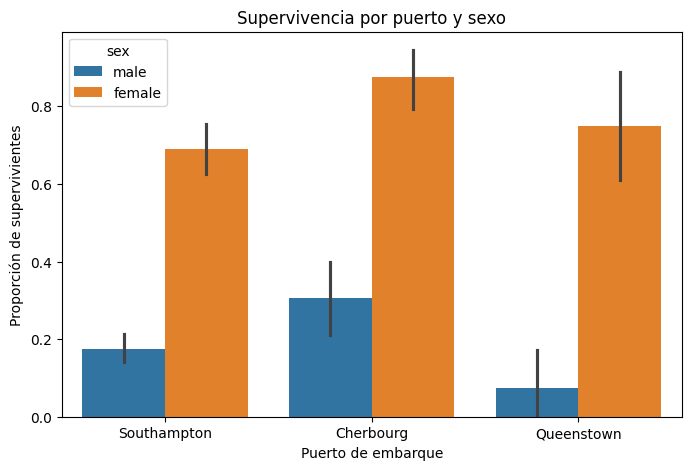

In [7]:


plt.figure(figsize=(8,5))

sns.barplot(
    data=titanic,
    x="embark_town",
    y="survived",
    hue="sex"
)

plt.title("Supervivencia por puerto y sexo")
plt.xlabel("Puerto de embarque")
plt.ylabel("Proporción de supervivientes")

plt.savefig("supervivencia_puerto_sexo.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

# Crear variable de niño
titanic["is_child"] = titanic["age"] < 18

# Filtrar mujeres y niños (incluye niños de ambos sexos)
grupo = titanic[(titanic["sex"] == "female") | (titanic["is_child"] == True)].copy()

# Crear etiqueta de grupo
grupo["grupo"] = grupo.apply(
    lambda x: "Niño" if x["is_child"] else "Mujer",
    axis=1
)

# Calcular tasa de supervivencia
tasas = grupo.groupby("grupo")["survived"].mean()
print(tasas)

grupo
Mujer    0.752896
Niño     0.539823
Name: survived, dtype: float64


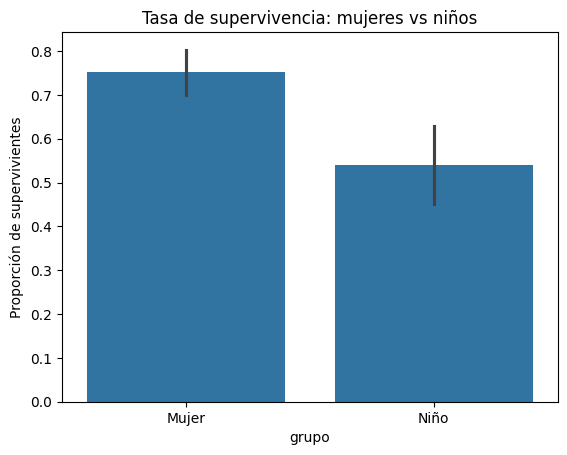

In [10]:
plt.figure()

sns.barplot(
    data=grupo,
    x="grupo",
    y="survived"
)

plt.title("Tasa de supervivencia: mujeres vs niños")
plt.ylabel("Proporción de supervivientes")

plt.savefig("supervivencia_mujeres_ninos.png", dpi=300, bbox_inches="tight")
plt.show()